# Импортирование необходимых функций

In [3]:
%run ./mdt_processing_functions.ipynb

# Создание html-дайджеста mdt-файла
Нужно указать путь к файлу. Отчет будет создан в текущей папке, если не указать *outdir*

In [5]:
create_afm_viewer_html(
    input_filename='./Test Files/a9312-02.mdt', outdir='./')

Загрузка файла: /home/elobanova/Загрузки/MDT9/a931/a9312-02.mdt
Обработка кадра 0: 1F:Height


/tmp/ipykernel_17149/3010913936.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Обработка кадра 1: 1F:Phase
Обработка кадра 2: 1F:Height
Обработка кадра 3: 1F:Phase
Обработка кадра 4: 1F:Height
Обработка кадра 5: 1F:Phase
Обработка кадра 6: 1F:Height
Обработка кадра 7: 1F:Phase
Обработка кадра 8: 1F:Height
Обработка кадра 9: 1F:Phase
Обработка кадра 10: 1F:Height
Обработка кадра 11: 1F:Height
Обработка кадра 12: 1F:Phase
Обработка кадра 13: 1F:Height
Обработка кадра 14: 1F:Phase
Обработка кадра 15: 1F:Height
Обработка кадра 16: 1F:Phase

✅ Отчет сохранен: ./9312 AFM 02_viewer.html
📊 Обработано кадров: 17


'./9312 AFM 02_viewer.html'

# Создание логбука в word

In [14]:
create_afm_report_docx(input_filename = './Test Files/a9312-02.mdt', 
                       operator = 'Jupyter', outdir = './')

Имя файла отчета: ./9312 AFM 02 jupyter.docx
Успех


{'filename': '/home/elobanova/Загрузки/MDT9/a931/a9312-02.mdt',
 'frames': [{'channel': '1F:Height',
   'size': 1.0,
   'RMS': 10.05,
   'RMS masked': 3.3503412668118693,
   'peak_to_peak': 149.31},
  {'channel': '1F:Phase',
   'size': 1.0,
   'RMS': 28484.05,
   'RMS masked': 17184.21158817023,
   'peak_to_peak': 231575.44},
  {'channel': '1F:Height',
   'size': 1.0,
   'RMS': 1.11,
   'RMS masked': 0.4337710616699578,
   'peak_to_peak': 21.07},
  {'channel': '1F:Phase',
   'size': 1.0,
   'RMS': 2213.67,
   'RMS masked': 1649.2131107957757,
   'peak_to_peak': 67359.31},
  {'channel': '1F:Height',
   'size': 0.3,
   'RMS': 0.23,
   'RMS masked': 0.11393760589013412,
   'peak_to_peak': 3.01},
  {'channel': '1F:Phase',
   'size': 0.3,
   'RMS': 1383.79,
   'RMS masked': 861.077972427627,
   'peak_to_peak': 13586.12},
  {'channel': '1F:Height',
   'size': 0.1,
   'RMS': 0.1,
   'RMS masked': 0.05763864351863507,
   'peak_to_peak': 0.98},
  {'channel': '1F:Phase',
   'size': 0.1,
   'RMS'

# Загрузка mdt-файла

In [11]:
mdt_file = MDTFile()
mdt_file.load_mdt_file('./Test Files/a9312-02.mdt')

# Визуализация всех фреймов

Объект класса MDTFile представляет собой список фреймов. 

У каждого фрейма есть такие полезные аттрибуты:
- frame.title: название фрейма
- frame.xreal, frame.yreal: размер изображения в нанометрах
- frame.data: сырое изображение

После обработки, то есть применения функции process_frame(frame):
- frame.data_corrected: данные после построчного вычитания фона, высоты в нанометрах
- frame.peak_to_peak: разброс высот в нанометрах
- frame.rms: среднеквадратичная шероховатость в нанометрах
- frame.rms_otsu: среднеквадратичная шероховатость без учета высоких островков
- frame.masked_otsu: изображение, из которого убраны отфильтрованные по Оцу значения

**ВНИМАНИЕ:** фильтрация по Оцу хорошо работает для изображений с редкими высокими островками и довольно плохо для гладких картинок

## 1. Сырые данные

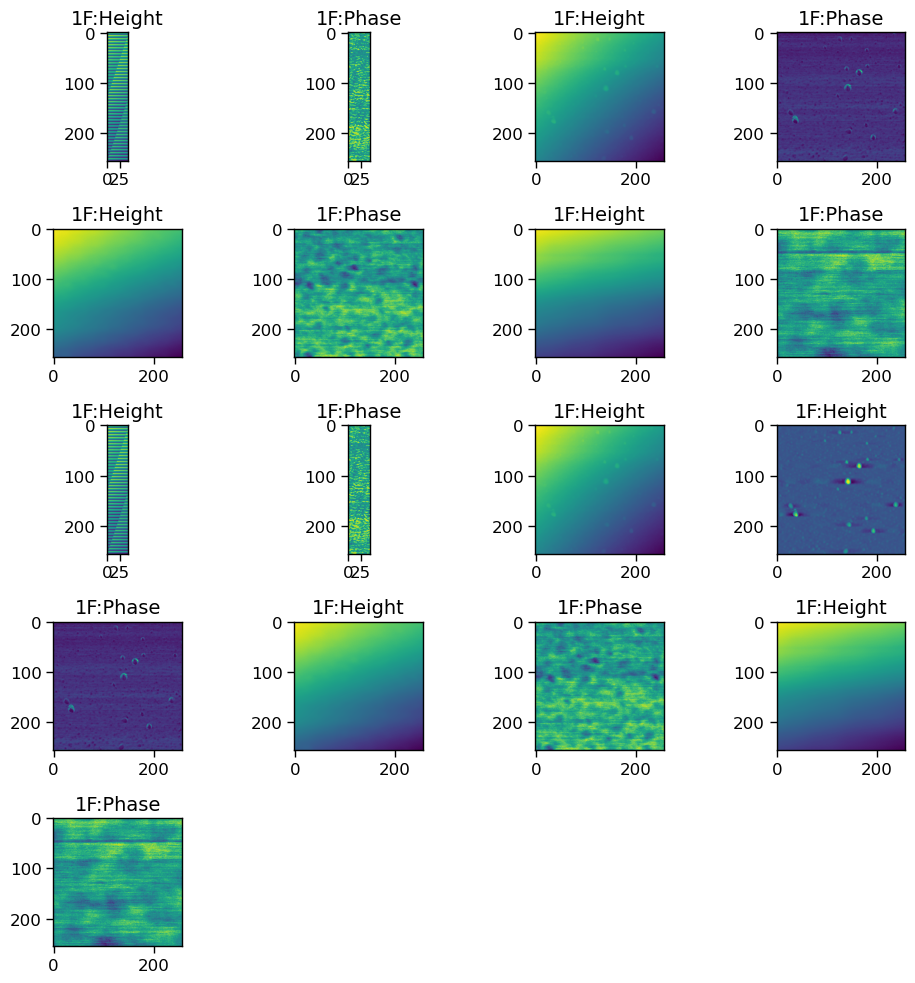

In [12]:
fig, axes = plt.subplots(len(mdt_file)//4 + 1, 4, figsize = (10, 10))
axes = axes.flatten()
for i, frame in enumerate(mdt_file):
    frame = process_frame(frame)
    axes[i].imshow(frame.data)
    #axes[i].text(10, 50, c = 'white')
    axes[i].set_title(frame.title)
    
for i in range(len(mdt_file), len(axes)): axes[i].remove()

plt.tight_layout()

## 2. Скорректированные данные

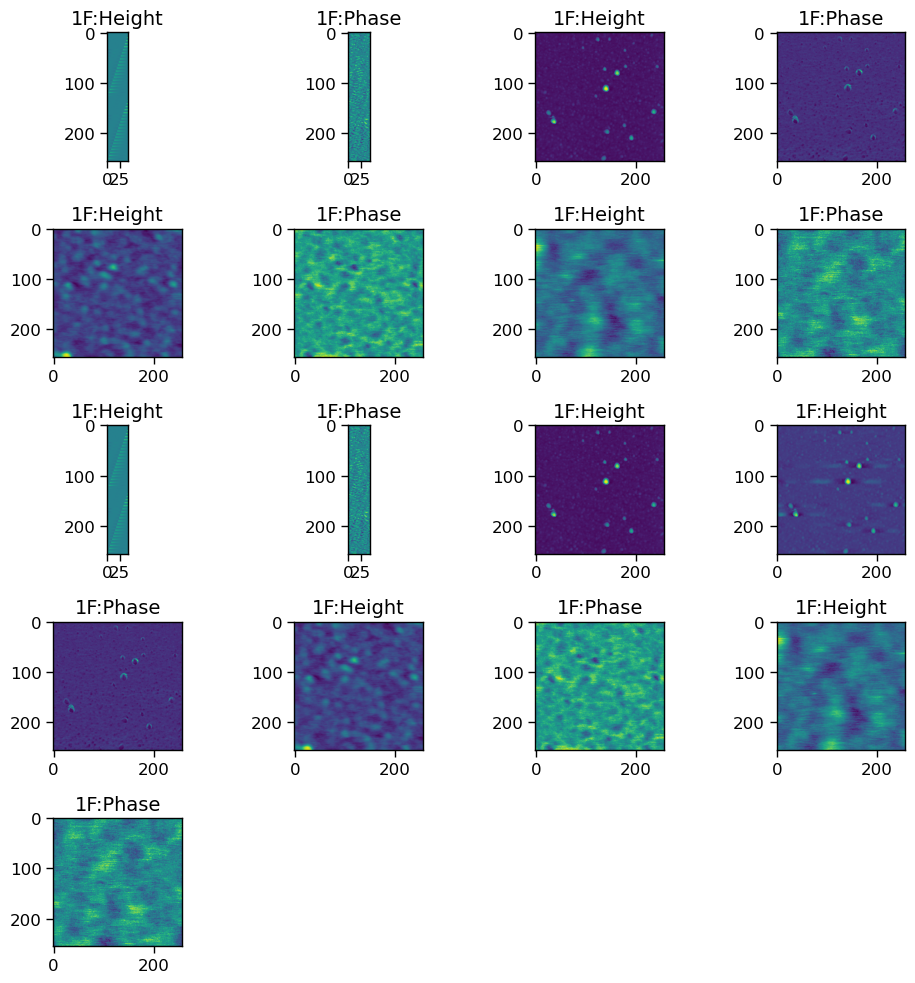

In [13]:
fig, axes = plt.subplots(len(mdt_file)//4 + 1, 4, figsize = (10, 10))
axes = axes.flatten()
for i, frame in enumerate(mdt_file):
    frame = process_frame(frame)
    axes[i].imshow(frame.data_corrected)
    #axes[i].text(10, 50, c = 'white')
    axes[i].set_title(frame.title)
    
for i in range(len(mdt_file), len(axes)): axes[i].remove()

plt.tight_layout()

# Картинки

In [17]:
mdt_file_9409_1 = MDTFile()
mdt_file_9409_1.load_mdt_file('/home/elobanova/Загрузки/MDT9/a940/a9409-1-01.mdt')

mdt_file_9410_1_1 = MDTFile()
mdt_file_9410_1_1.load_mdt_file('/home/elobanova/Загрузки/MDT9/a941/a9410-1-01.mdt')

mdt_file_9410_1_2 = MDTFile()
mdt_file_9410_1_2.load_mdt_file('/home/elobanova/Загрузки/MDT9/a941/a9410-1-02.mdt')

mdt_file_9410_1_3 = MDTFile()
mdt_file_9410_1_3.load_mdt_file('/home/elobanova/Загрузки/MDT9/a941/a9410-1-03.mdt')

mdt_file_9420A = MDTFile()
mdt_file_9420A.load_mdt_file('/home/elobanova/Загрузки/MDT9/a942/a9420A-01.mdt')

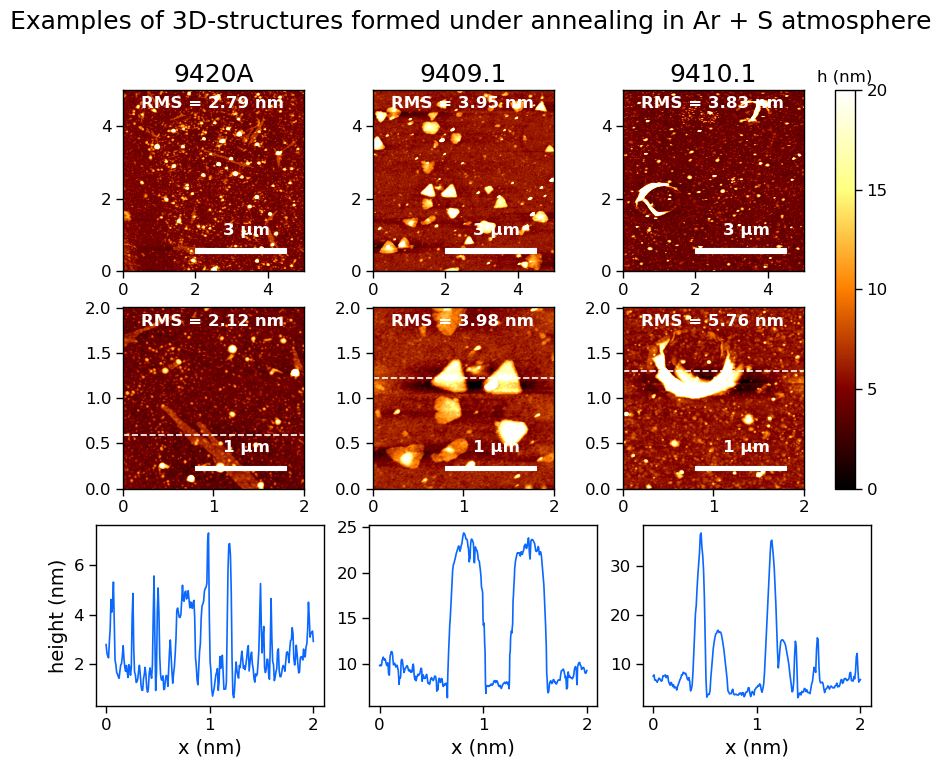

In [27]:
sns.set_context('paper')

bluetiful = '#0B68FE'
honey = '#ffcc33'
tart = '#f93f37'
lizard = '#d0ff14'
violet = '#7f00ff'

plt.rcParams.update({
    'font.size': 12,              # Основной размер шрифта
    'axes.titlesize': 18,          # Размер заголовка
    'axes.labelsize': 14,          # Размер подписей осей
    'xtick.labelsize': 12,         # Размер подписей делений по X
    'ytick.labelsize': 12,         # Размер подписей делений по Y
    'legend.fontsize': 12,         # Размер шрифта легенды
    'figure.titlesize': 18,        # Размер заголовка фигуры
})

framelist = [mdt_file_9420A[0], mdt_file_9409_1[5], mdt_file_9410_1_3[0], 
            mdt_file_9420A[2], mdt_file_9409_1[7], mdt_file_9410_1_3[5]]

for frame in framelist: frame = process_frame(frame)

fig, axes = plt.subplots(3, 3, figsize = (10, 8))
axes = axes.flatten()

axes[0].imshow(mdt_file_9420A[0].data_corrected + 2, vmin = 0, vmax = 20, extent = [0, mdt_file_9420A[0].xreal, 0, mdt_file_9420A[0].yreal], cmap = 'afmhot')
axes[1].imshow(mdt_file_9409_1[5].data_corrected -0.5, vmin = 0, vmax = 20, extent = [0, mdt_file_9420A[0].xreal, 0, mdt_file_9420A[0].yreal], cmap = 'afmhot')
axes[2].imshow(mdt_file_9410_1_3[0].data_corrected + 2, vmin = 0, vmax = 20, extent = [0, mdt_file_9420A[0].xreal, 0, mdt_file_9420A[0].yreal], cmap = 'afmhot')
axes[3].imshow(mdt_file_9420A[2].data_corrected + 2, vmin = 0, vmax = 20, extent = [0, frame.xreal, 0, frame.yreal], cmap = 'afmhot')
axes[4].imshow(mdt_file_9409_1[7].data_corrected -3, vmin = 0, vmax = 20, extent = [0, frame.xreal, 0, frame.yreal], cmap = 'afmhot')
im = axes[5].imshow(mdt_file_9410_1_3[5].data_corrected -1, vmin = 0, vmax = 20, extent = [0, frame.xreal, 0, frame.yreal], cmap = 'afmhot')


for i, frame in enumerate(framelist):

    axes[i].text(frame.xreal*0.55, frame.yreal*0.2, f'{round(frame.xreal/2)} µm', c = 'white', weight='bold')
    
    axes[i].text(frame.xreal*0.1, frame.yreal*0.9, f'RMS = {round(frame.rms, 2)} nm', c = 'white', weight='bold')
    
    axes[i].add_patch(Rectangle((frame.xreal*0.4, frame.yreal*0.1), frame.xreal/2, frame.xreal/40, color='white'))


x = np.linspace(0, 2, 256)
axes[3].axhline(2 - 180/256*2, c = 'white', ls = '--')
axes[6].plot(x, mdt_file_9420A[2].data_corrected[180], c = bluetiful)
axes[6].set_ylabel('height (nm)')
axes[6].set_xlabel('x (nm)')

x = np.linspace(0, 2, 512)
axes[4].axhline(2 - 200/512*2, c = 'white', ls = '--')
axes[7].plot(x, mdt_file_9409_1[7].data_corrected[200], c = bluetiful)
#axes[7].set_ylabel('height (nm)')
axes[7].set_xlabel('x (nm)')

x = np.linspace(0, 2, 256)
axes[5].axhline(2 - 90/256*2, c = 'white', ls = '--')
axes[8].plot(x, mdt_file_9410_1_3[5].data_corrected[90], c = bluetiful)
#axes[8].set_ylabel('height (nm)')
axes[8].set_xlabel('x (nm)')

    
axes[0].set_title('9420A')
axes[1].set_title('9409.1')
axes[2].set_title('9410.1')
cbar = plt.colorbar(im, ax=axes[:6].ravel().tolist(), fraction=0.046, pad=0.04, ticks = [0, 5, 10, 15, 20])
cbar.ax.set_title('h (nm)', fontsize = 12)
plt.suptitle('Examples of 3D-structures formed under annealing in Ar + S atmosphere')
#plt.tight_layout()    
plt.show()